# Homework Assignment Solution: Linear Regression

BINF 6210/8210: Machine Learning for Bioinformatics
___

This notebook provides one defensible solution. Alternative scientifically justified choices may receive full credit.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

import statsmodels.api as sm

In [2]:
# load the diabetes data
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(as_frame=True)
X = diabetes.data
y = diabetes.target

### Part A: Data exploration

In [3]:
# get an overview of the data

print('Shape of X:', X.shape)
print('Shape of y:', y.shape)

print()
print(X.head())

Shape of X: (442, 10)
Shape of y: (442,)

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  


In [4]:
# 1. Report the number of observations and predictors

print('Number of observations:', X.shape[0])
print('Number of predictors:', X.shape[1])
print('\nThe predictors are: ', X.columns.tolist())

Number of observations: 442
Number of predictors: 10

The predictors are:  ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


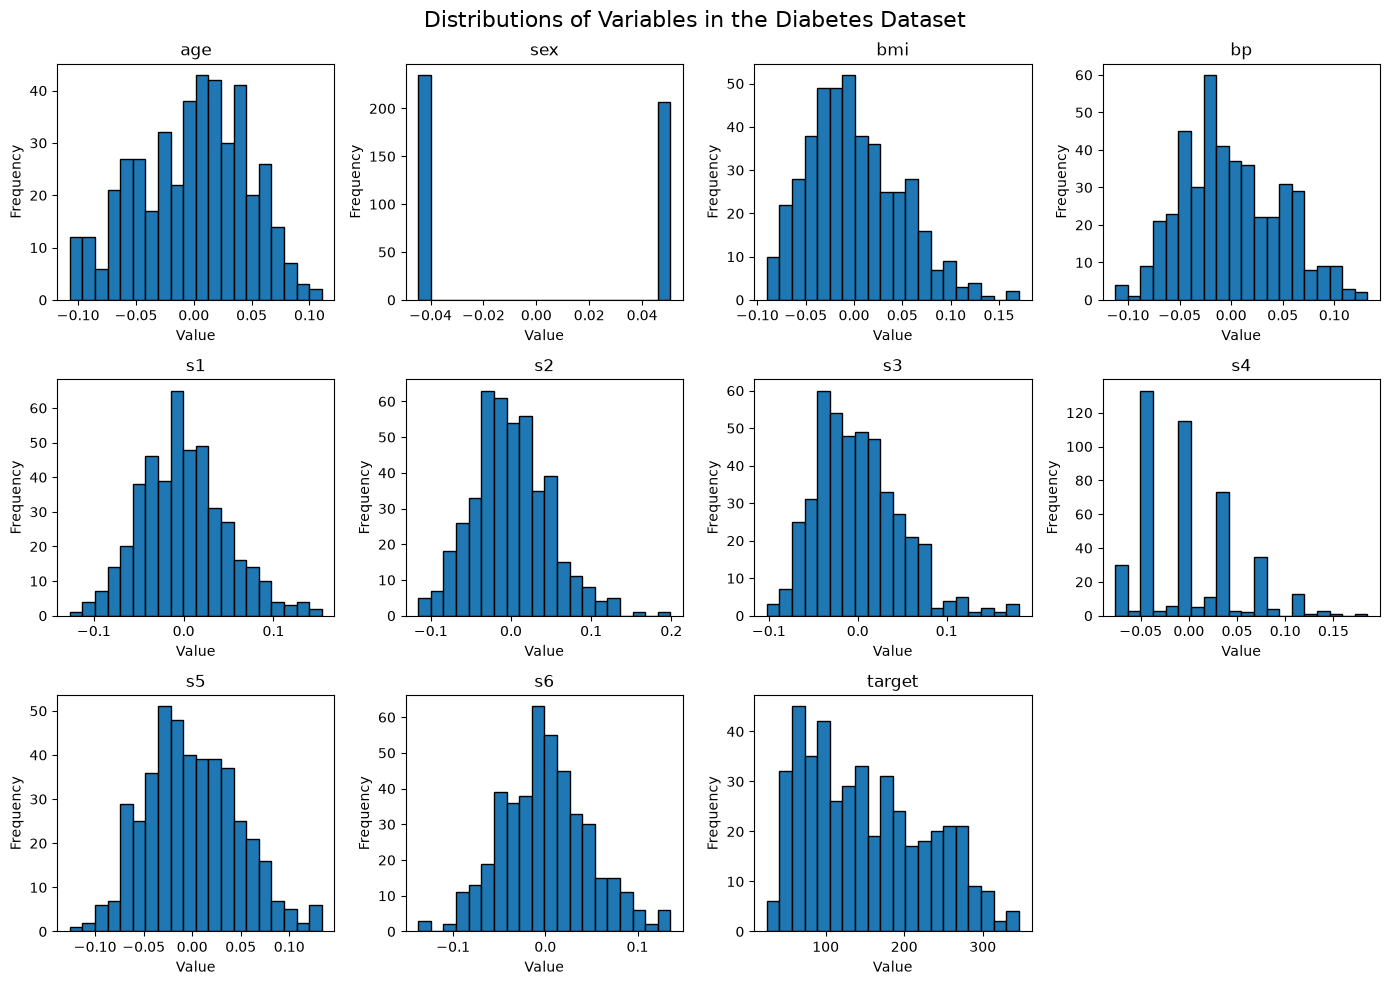

In [7]:
# 2. Examine the distributions of the predictors and outcome.

df = X.copy()
df['target'] = y

fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(14, 10)
)

axes = axes.flatten()

for i, column in enumerate(df.columns):
    axes[i].hist(
        df[column],
        bins=20,
        edgecolor="black"
    )

    axes[i].set_title(column)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Frequency")

# There are 12 subplot positions but only 11 variables, so remove the unused subplot.
for j in range(len(df.columns), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Distributions of Variables in the Diabetes Dataset",
    fontsize=16
)

plt.tight_layout()
plt.show()


In [9]:
# 3. Calculate correlations between each predictor and the outcome

df = X.copy()
df["target"] = y

correlations = df.corr()["target"].drop("target")

# sort correlations by magnitude, regardless of positive or negative direction
correlations = correlations.sort_values(
    key=lambda x: x.abs(),
    ascending=False
)

print("\nCorrelations with disease progression:")
print(correlations)



Correlations with disease progression:
bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s3    -0.394789
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
Name: target, dtype: float64


In [10]:
# 4. Identify the three predictors with the strongest absolute correlations with disease progression.

print(correlations[:3])

bmi    0.586450
s5     0.565883
bp     0.441482
Name: target, dtype: float64


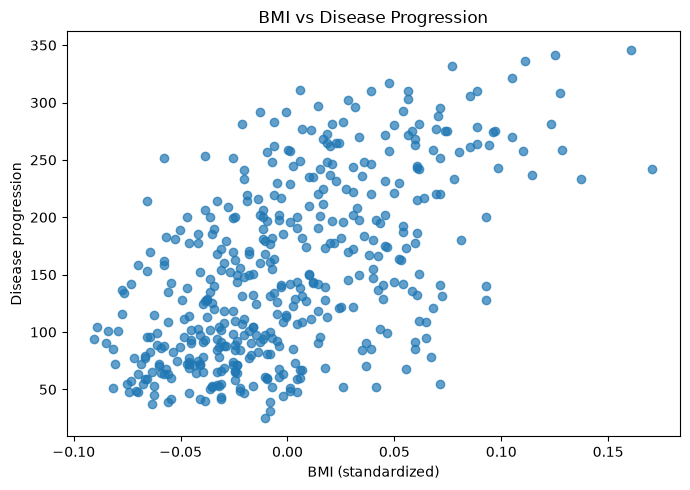

In [11]:
# 5. Create a scatterplot of BMI versus disease progression. Describe teh apparent relationship

plt.figure(figsize=(7, 5))
plt.scatter(X["bmi"], y, alpha=0.7)
# alpha controls the transparency of the plotted data points. At alpha=0.7, data points are slightly see-through.
# alpha is highly useful for visualizing data density.

plt.xlabel("BMI (standardized)")
plt.ylabel("Disease progression")
plt.title("BMI vs Disease Progression")

plt.tight_layout()
plt.show()

In [12]:
print('The scatter plot indicates that there is a linear relationship between BMI and disease progression.')

The scatter plot indicates that there is a linear relationship between BMI and disease progression.


### Part B. Simple linear regression

$$
y = \beta_0 + \beta_1 \times \text{BMI} + \epsilon
$$

In [13]:
# 1. Split the data into 80% training and 20% testing using random_state=42

X_bmi = X[["bmi"]]

X_train_bmi, X_test_bmi, y_train, y_test = train_test_split(
    X_bmi,
    y,
    test_size=0.20,
    random_state=42
)

In [15]:
# 2. Fit the model using the training data
simple_model = LinearRegression()
simple_model.fit(X_train_bmi, y_train)

print("\n" + "=" * 60)
print("SIMPLE LINEAR REGRESSION")
print("=" * 60)

# 3. Report the intercept and BMI coefficient
print("Intercept:", simple_model.intercept_)
print("BMI coefficient:", simple_model.coef_[0])
print(simple_model)


SIMPLE LINEAR REGRESSION
Intercept: 152.00335421448167
BMI coefficient: 998.5776891375593
LinearRegression()


4. Interpret the BMI coefficient: For one unit increase in BMI, the expected diabetes progression increases by 998 units.

In [16]:
# 5. Calculate the training and testing R2 and RMSE

y_train_pred_simple = simple_model.predict(X_train_bmi)
y_test_pred_simple = simple_model.predict(X_test_bmi)

# Model performance
train_r2_simple = r2_score(y_train, y_train_pred_simple)
test_r2_simple = r2_score(y_test, y_test_pred_simple)

train_rmse_simple = np.sqrt(
    mean_squared_error(y_train, y_train_pred_simple)
)

test_rmse_simple = np.sqrt(
    mean_squared_error(y_test, y_test_pred_simple)
)

train_mae_simple = mean_absolute_error(
    y_train,
    y_train_pred_simple
)

test_mae_simple = mean_absolute_error(
    y_test,
    y_test_pred_simple
)

print("\nTraining performance")
print("R^2:", train_r2_simple)
print("RMSE:", train_rmse_simple)
print("MAE:", train_mae_simple)

print("\nTesting performance")
print("R^2:", test_r2_simple)
print("RMSE:", test_rmse_simple)
print("MAE:", test_mae_simple)




Training performance
R^2: 0.3657241273794126
RMSE: 62.081500079136454
MAE: 51.37972765404719

Testing performance
R^2: 0.23335039815872138
RMSE: 63.73245584860925
MAE: 52.25997644534553


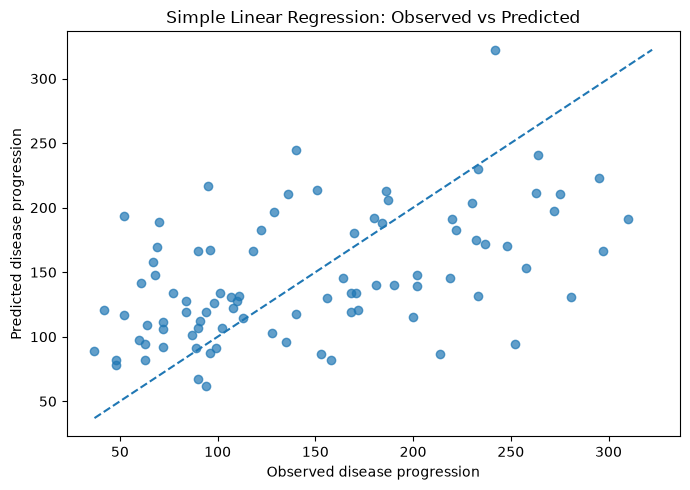

In [17]:
# 6. Plot the observed test outcomes vs predicted outcomes

plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    y_test_pred_simple,
    alpha=0.7
)

minimum = min(y_test.min(), y_test_pred_simple.min())
maximum = max(y_test.max(), y_test_pred_simple.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Observed disease progression")
plt.ylabel("Predicted disease progression")
plt.title("Simple Linear Regression: Observed vs Predicted")

plt.tight_layout()
plt.show()


### Part C. Multiple linear regression

In [18]:
# 1. Report the estimated coefficients.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

multiple_model = LinearRegression()

multiple_model.fit(X_train, y_train)

print("\n" + "=" * 60)
print("MULTIPLE LINEAR REGRESSION")
print("=" * 60)

print("Intercept:", multiple_model.intercept_)


# ------------------------------------------------------------
# Display coefficients
# ------------------------------------------------------------

coefficients = pd.Series(
    multiple_model.coef_,
    index=X.columns,
    name="Coefficient"
)

print("\nRegression coefficients:")
print(coefficients)


MULTIPLE LINEAR REGRESSION
Intercept: 151.34560453985995

Regression coefficients:
age     37.904021
sex   -241.964362
bmi    542.428759
bp     347.703844
s1    -931.488846
s2     518.062277
s3     163.419983
s4     275.317902
s5     736.198859
s6      48.670657
Name: Coefficient, dtype: float64


In [19]:
# 2. Compare its training and testing R2 and RMSE with the BMI-only model.

y_train_pred_multiple = multiple_model.predict(X_train)
y_test_pred_multiple = multiple_model.predict(X_test)


# Compare its training and testing R2 and RMSE with the BMI-only model.
train_r2_multiple = r2_score(
    y_train,
    y_train_pred_multiple
)

test_r2_multiple = r2_score(
    y_test,
    y_test_pred_multiple
)

train_rmse_multiple = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_multiple
    )
)

test_rmse_multiple = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_multiple
    )
)

train_mae_multiple = mean_absolute_error(
    y_train,
    y_train_pred_multiple
)

test_mae_multiple = mean_absolute_error(
    y_test,
    y_test_pred_multiple
)

print("\nTraining performance")
print("R^2:", train_r2_multiple)
print("RMSE:", train_rmse_multiple)
print("MAE:", train_mae_multiple)

print("\nTesting performance")
print("R^2:", test_r2_multiple)
print("RMSE:", test_rmse_multiple)
print("MAE:", test_mae_multiple)



Training performance
R^2: 0.5279193863361497
RMSE: 53.55884336723094
MAE: 43.483503523980396

Testing performance
R^2: 0.4526027629719196
RMSE: 53.85344583676592
MAE: 42.79409467959994


In [20]:
# Compare simple and multiple regression models

comparison = pd.DataFrame({
    "Model": [
        "BMI only",
        "All predictors"
    ],
    "Train R^2": [
        train_r2_simple,
        train_r2_multiple
    ],
    "Test R^2": [
        test_r2_simple,
        test_r2_multiple
    ],
    "Train RMSE": [
        train_rmse_simple,
        train_rmse_multiple
    ],
    "Test RMSE": [
        test_rmse_simple,
        test_rmse_multiple
    ],
    "Train MAE": [
        train_mae_simple,
        train_mae_multiple
    ],
    "Test MAE": [
        test_mae_simple,
        test_mae_multiple
    ]
})

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(comparison)


MODEL COMPARISON
            Model  Train R^2  Test R^2  Train RMSE  Test RMSE  Train MAE  \
0        BMI only   0.365724  0.233350   62.081500  63.732456  51.379728   
1  All predictors   0.527919  0.452603   53.558843  53.853446  43.483504   

    Test MAE  
0  52.259976  
1  42.794095  


In [ ]:
# Based on the comparison, the multiple linear regression performs better on unseen data because the test RMSE and test MAE are smaller.

4. Identify the three predictors with the largest absolute regression coefficients. Does this necessarily mean that these variables are the three most biologically important predictors.

The three largest coefficients in absolute magnitude are:
- s1 = -931.49
- s2 = 736.20
- bmi = 542.43

However, we should not conclude that these are necessarily the three most biologically important variables.

Regression coefficient magnitude can depend on:

- predictor scaling,
- correlations between predictors,
- multicollinearity,
- model specification,
- interactions,
- nonlinear effects.

In this particular dataset the variables are similarly scaled, which makes coefficient comparison somewhat more meaningful, but multicollinearity still complicates interpretation.

### Part D: Model diagnostics

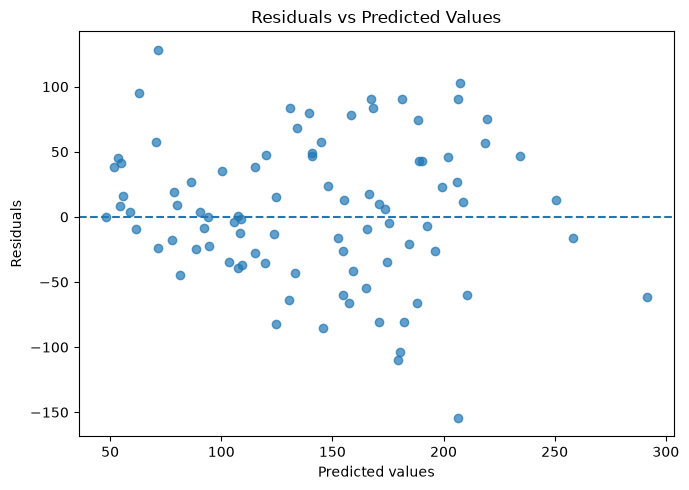

In [21]:
# 1. Plot residuals versus predicted values

residuals = y_test - y_test_pred_multiple

# ------------------------------------------------------------
# Residuals vs fitted values
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.scatter(
    y_test_pred_multiple,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.tight_layout()
plt.show()

The residual-vs-predicted plot should show residuals distributed on both sides of zero.

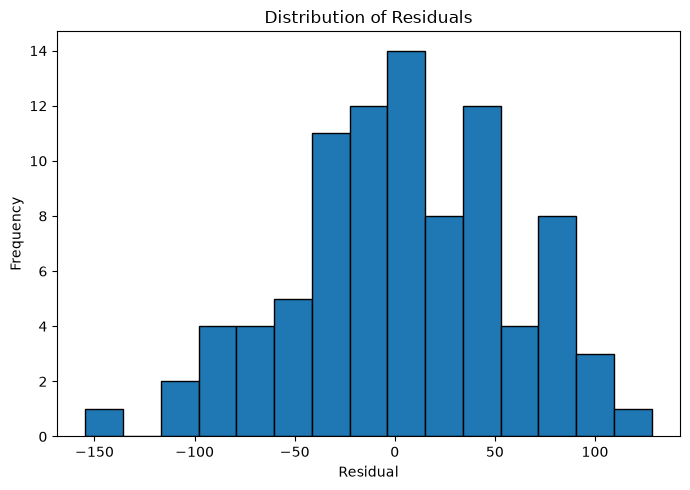

In [22]:
# 2. Plot the distribution of residuals

plt.figure(figsize=(7, 5))

plt.hist(
    residuals,
    bins=15,
    edgecolor="black"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.tight_layout()
plt.show()

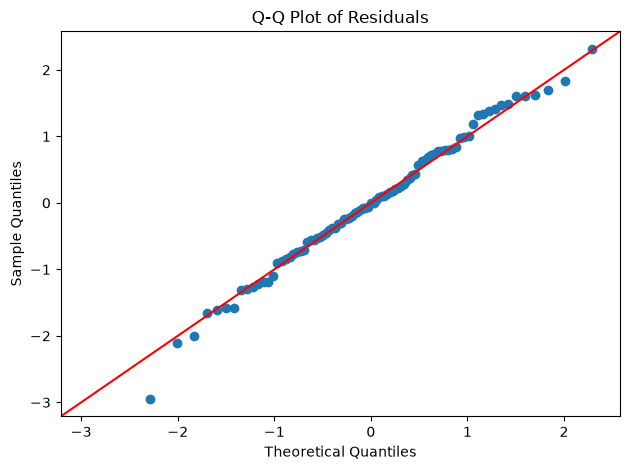

In [23]:
# ------------------------------------------------------------
# Q-Q plot
# ------------------------------------------------------------

sm.qqplot(
    residuals,
    line="45",
    fit=True
)

plt.title("Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()


3. Discuss whether the residuals appear consistent with the assumptions of constant variance and approximate normality.

**Constant variance:** The residual-vs-predicted plot shows residuals distributed around zero across the range of fitted values. There may be some variation in the spread, but there is no strong funnel-shaped pattern. Therefore, the constant-variance assumption appears reasonably satisfied, although not perfectly.

**Normality:** The residual histogram is approximately centered around zero and reasonably symmetric. Most points in the Q-Q plot lie relatively close to the reference line, although some departures occur in the tails. Therefore, the residuals appear approximately normal, with modest deviations from perfect normality.

In [24]:
# 4. Investigate correlations among the predictor variables. Are there predictors that may introduce mul-ticollinearity?

correlation_matrix = X.corr()

print("\nPredictor correlation matrix:")
print(correlation_matrix.round(2))


Predictor correlation matrix:
      age   sex   bmi    bp    s1    s2    s3    s4    s5    s6
age  1.00  0.17  0.19  0.34  0.26  0.22 -0.08  0.20  0.27  0.30
sex  0.17  1.00  0.09  0.24  0.04  0.14 -0.38  0.33  0.15  0.21
bmi  0.19  0.09  1.00  0.40  0.25  0.26 -0.37  0.41  0.45  0.39
bp   0.34  0.24  0.40  1.00  0.24  0.19 -0.18  0.26  0.39  0.39
s1   0.26  0.04  0.25  0.24  1.00  0.90  0.05  0.54  0.52  0.33
s2   0.22  0.14  0.26  0.19  0.90  1.00 -0.20  0.66  0.32  0.29
s3  -0.08 -0.38 -0.37 -0.18  0.05 -0.20  1.00 -0.74 -0.40 -0.27
s4   0.20  0.33  0.41  0.26  0.54  0.66 -0.74  1.00  0.62  0.42
s5   0.27  0.15  0.45  0.39  0.52  0.32 -0.40  0.62  1.00  0.46
s6   0.30  0.21  0.39  0.39  0.33  0.29 -0.27  0.42  0.46  1.00


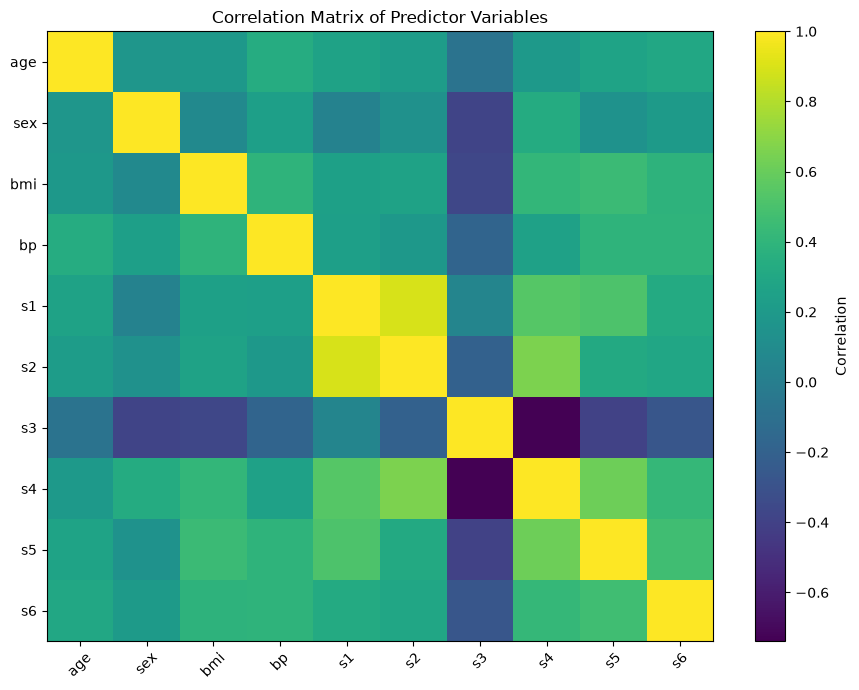

In [25]:
# ------------------------------------------------------------
# Visualize correlation matrix
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(X.columns)),
    X.columns,
    rotation=45
)

plt.yticks(
    range(len(X.columns)),
    X.columns
)

plt.title("Correlation Matrix of Predictor Variables")

plt.tight_layout()
plt.show()

The correlation matrix shows substantial correlations among several predictor variables, particularly the serum measurements. The strongest correlation is between $s_1$ and $s_2$ (\($r \approx0.90$\)), indicating that these two predictors contain highly overlapping information. Other notable correlations include $s_3$ and $s_4$ (\($r \approx-0.74$ \)) and $s_4$ and $s_5$ (\($r \approx0.62$ \)). These correlations suggest that multicollinearity may be present in the multiple linear regression model, particularly among the serum-related predictors.

Multicollinearity does not necessarily reduce the model's predictive accuracy, but it can make individual regression coefficients unstable and difficult to interpret. For example, correlated predictors may have unexpectedly large coefficients, changing signs, or large standard errors because the model has difficulty separating their individual contributions to the outcome.

Multicollinearity can:

- inflate coefficient variance,
- produce unstable coefficients,
- change coefficient signs or magnitudes,
- make individual predictor interpretation difficult.

At the same time, predictive accuracy can remain reasonably good because correlated variables may collectively carry useful predictive information.